In [2]:
import os
print(os.getcwd())

/Users/anitanam


In [3]:
import os
os.chdir("/Users/anitanam/optical_materials_ml")
print(os.getcwd())

/Users/anitanam/optical_materials_ml


In [4]:
import pandas as pd

jarvis = pd.read_parquet("data/raw/jarvis_dft3d.parquet")
jarvis.shape

(75993, 12)

In [5]:
from pymatgen.core import Composition

def to_reduced_formula(formula):
    try:
        return Composition(formula).reduced_formula
    except:
        return None

jarvis["reduced_formula"] = jarvis["formula"].apply(to_reduced_formula)

ri_df = jarvis[["reduced_formula", "refractive_index"]].dropna(subset=["refractive_index"])
ri_df = ri_df.groupby("reduced_formula", as_index=False).median(numeric_only=True)

ri_df.shape

/opt/homebrew/Cellar/python@3.14/3.14.6/Frameworks/Python.framework/Versions/3.14/lib/python3.14/functools.py:1126: UserWarning: No Pauling electronegativity for He. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  val = self.func(instance)
/opt/homebrew/Cellar/python@3.14/3.14.6/Frameworks/Python.framework/Versions/3.14/lib/python3.14/functools.py:1126: UserWarning: No Pauling electronegativity for Ar. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  val = self.func(instance)
/opt/homebrew/Cellar/python@3.14/3.14.6/Frameworks/Python.framework/Versions/3.14/lib/python3.14/functools.py:1126: UserWarning: No Pauling electronegativity for Ne. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  val = self.func(instance)


(37626, 2)

In [6]:
ri_df["refractive_index"].describe()

count    37626.000000
mean         6.816889
std          4.210153
min          0.124097
25%          2.889978
50%          6.056261
75%         10.034232
max         19.954998
Name: refractive_index, dtype: float64

<Axes: >

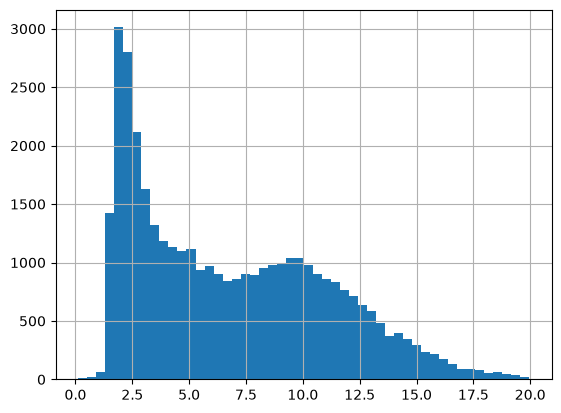

In [7]:
ri_df["refractive_index"].hist(bins=50)

In [8]:
from pymatgen.core import Composition

ri_df["composition"] = (
    ri_df["reduced_formula"]
    .apply(Composition)
)

In [9]:
sample = ri_df.head(10).copy()

In [10]:
from matminer.featurizers.composition import ElementProperty

featurizer = ElementProperty.from_preset("magpie")

/opt/homebrew/Cellar/jupyterlab/4.5.8_1/libexec/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
sample_features = featurizer.featurize_dataframe(
    sample,
    col_id="composition",
    ignore_errors=True
)

sample_features.shape

ElementProperty: 100%|█████████████████████████| 10/10 [00:00<00:00, 61.81it/s]


(10, 135)

In [12]:
ri_features = featurizer.featurize_dataframe(
    ri_df.copy(),
    col_id="composition",
    ignore_errors=True,
    pbar=True
)

ElementProperty: 100%|███████████████████| 37626/37626 [15:55<00:00, 39.40it/s]


In [13]:
import os

ri_features = ri_features.drop(columns=["composition"])
ri_features.shape

(37626, 134)

In [14]:
os.makedirs("notebooks/data/processed", exist_ok=True)

ri_features.to_parquet(
    "notebooks/data/processed/refractive_index_features.parquet",
    index=False
)

In [15]:
import pandas as pd

check = pd.read_parquet("notebooks/data/processed/refractive_index_features.parquet")
check.shape

(37626, 134)

In [16]:
jarvis.columns

Index(['jid', 'formula', 'optb88vdw_bandgap', 'mbj_bandgap',
       'formation_energy_peratom', 'ehull', 'epsx', 'epsy', 'epsz', 'slme',
       'refractive_index', 'source_db', 'reduced_formula'],
      dtype='object')

In [18]:
ri_master = jarvis[
    [
        "reduced_formula",
        "refractive_index",
        "optb88vdw_bandgap",
        "mbj_bandgap",
        "formation_energy_peratom",
        "ehull",
        "epsx",
        "epsy",
        "epsz",
        "slme"
    ]
].copy()

ri_master = ri_master.dropna(
    subset=["refractive_index"]
)

ri_master.shape

(52168, 10)

In [19]:
ri_master = ri_master.merge(
    mp_density,
    on="reduced_formula",
    how="left"
)

ri_master.shape

(52168, 11)

In [20]:
ri_master.isna().sum()

reduced_formula                 0
refractive_index                0
optb88vdw_bandgap               0
mbj_bandgap                 33864
formation_energy_peratom        0
ehull                           0
epsx                            0
epsy                            0
epsz                            0
slme                        42958
density                     35769
dtype: int64

In [3]:
# 1) Drop extremely sparse columns for the main model
ri_model = ri_master.drop(columns=["mbj_bandgap", "slme"])

# 2) Look at what remains
ri_model.shape
ri_model.isna().sum()

NameError: name 'ri_master' is not defined